# Predicting Cybersecurity Incidents: Data Analysis

Before conducting the actual data analysis to predict cybercrime incidents, it's important to conduct some background research on the topic.

Below, I've gathered information about major high-tech releases throughout the year:

* **January**: High-tech season kicks off with most high-tech companies sharing their latest innovations and future plans.
* **June**: Companies start announcing new hardware releases, designs, and innovations.
* **September to October**: The high-tech industry reaches its peak season with major product releases and technological advancements.
* **November to December**: The focus shifts towards the holiday shopping season, with continued product releases and updates.


#### Timeline of High-Tech Product Releases

| Month          | Major Events and Releases                                       |
|----------------|-----------------------------------------------------------------|
| **January**    | **Consumer Electronics Show (CES)**                             |
|                | - Major tech companies unveil latest innovations and products   |
|                | - Focus on consumer electronics, IoT, and emerging technologies |
|                |                                                                 |
| **March-April**| **Spring Events**                                               |
|                | - Apple sometimes holds special events (e.g., new iPads)        |
|                | - Releases to create distance from holiday season               |
|                |                                                                 |
| **June**       | **Apple Worldwide Developers Conference (WWDC)**                |
|                | - Major software updates for iOS, macOS, watchOS, and tvOS      |
|                | - Occasional hardware announcements                             |
|                |                                                                 |
|                | **Microsoft and Other Tech Events**                             |
|                | - Significant updates and product announcements                 |
|                |                                                                 |
| **September**  | **Apple's Major Product Launch**                                |
| **October**    | - New iPhones, Apple Watches, and other significant products    |
|                |                                                                 |
|                | **Google's Pixel Event**                                        |
|                | - Announcements of new Pixel phones and other Google hardware   |
|                |                                                                 |
|                | **Other Tech Announcements**                                    |
|                | - Releases ahead of the holiday season                          |
|                |                                                                 |
| **November**   | **Microsoft and Other Tech Events**                             |
|                | - Product releases aimed at the holiday shopping season         |
|                | - Focus on consumer and enterprise products                     |

#### Summary

| Month            | Key Events                                                   |
|------------------|--------------------------------------------------------------|
| **January**      | CES                                                          |
| **March-April**  | Spring events (e.g., Apple iPads)                            |
| **June**         | WWDC (Apple software updates), other tech announcements      |
| **September-October** | Major product launches (e.g., Apple iPhones, Google Pixel) |
| **November**     | Pre-holiday releases (e.g., Microsoft)                       |


#### Correlation Between New Releases and Increased Device Bugs, Software Inconsistencies, and Cyber Criminality

## 1. New Device Bugs and Inconsistencies in Software Services
- **Complexity of New Features**: New devices and software updates often come with complex new features that haven't been tested extensively in real-world scenarios. This can lead to unforeseen bugs and inconsistencies.
- **Inadequate Testing Time**: Companies may face tight deadlines to release products, especially if they aim to align with major events or holiday seasons. This rush can result in less rigorous testing, leading to bugs.
- **Hardware-Software Integration**: New hardware often requires new drivers and firmware. The interaction between new hardware and existing software can introduce compatibility issues and bugs.
- **User Feedback Loop**: After a new release, companies rely on user feedback to identify and fix issues. The initial period after a release typically sees a spike in reported bugs as more users start using the new features.

## 2. Increased Cyber Criminality
- **Exploitable Vulnerabilities**: New products and updates may introduce new vulnerabilities that cybercriminals can exploit. Until these vulnerabilities are identified and patched, they pose a security risk.
- **Increased Attention**: High-profile releases attract the attention of cybercriminals looking to exploit the hype. For example, phishing campaigns often coincide with major product launches to trick users into divulging personal information.
- **Lag in Security Updates**: Users may not immediately apply patches or updates, leaving their devices vulnerable. Cybercriminals take advantage of this window of opportunity.
- **Targeting Early Adopters**: Early adopters of new technology may not be as vigilant about security practices, making them prime targets for cybercriminals.

## Examples and Evidence
- **iOS and Android Releases**: Major updates to operating systems like iOS and Android often come with initial bugs that need subsequent patches. The introduction of new features can also lead to security vulnerabilities that are quickly targeted by hackers.
- **High-Profile Cyber Attacks**: Following significant product launches, there have been instances of increased cybercriminal activity. For instance, new versions of Windows have historically seen a spike in targeted malware attacks shortly after release.
- **Security Reports**: Annual security reports from companies like Symantec and McAfee often highlight the correlation between new tech releases and a temporary increase in cyber threats and vulnerabilities.

## Conclusion
While the release of new products and updates is crucial for technological advancement, it is accompanied by an increase in bugs, software inconsistencies, and cybercriminal activity. Companies often address these issues through patches and updates post-release, but there is always an initial period of vulnerability that users and organizations must navigate carefully.


#### Dataset preparation

The supplied Federal Police CSV is exported in a **wide, semicolon-separated format**. 
The notebook below reshapes it automatically into a tidy dataset with three columns: 
`year`, `month`, and `total`.

The current dataset contains monthly cybercrime reports for **2016–2025** for the Leuven arrondissement.

In [28]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# CSV file. Keep the CSV in the same folder as this notebook.
csv_path = Path('transposed20162025.csv')

# The police export is semicolon-separated and arranged horizontally.
# Row 1 = years, row 2 = months, row 3 = cybercrime totals.
raw = pd.read_csv(
    csv_path,
    sep=';',
    header=None,
    skiprows=1,
    nrows=3,
    engine='python'
)

years = pd.to_numeric(raw.iloc[0, 1:], errors='coerce')
months = raw.iloc[1, 1:].astype(str).str.strip().str.lower()
totals = pd.to_numeric(raw.iloc[2, 1:], errors='coerce')

transposed = pd.DataFrame({
    'year': years.to_numpy(),
    'month': months.to_numpy(),
    'total': totals.to_numpy()
}).dropna()

transposed['year'] = transposed['year'].astype(int)
transposed['total'] = transposed['total'].astype(int)

transposed.head()


,year,month,total


In [29]:
# Preview the first few rows & basic info
print(transposed.dtypes)
transposed.head(10)

year      int64
month    object
total     int64
dtype: object


,year,month,total


In [30]:
# explore dataset size
transposed.size

0

The cleaned dataset has **120 observations**: 12 months × 10 years (2016–2025).

In [31]:
# explore the data types
transposed.dtypes

year      int64
month    object
total     int64
dtype: object

In [32]:
transposed.describe()

,year,total
count,0.0,0.0
mean,NaN,NaN
std,NaN,NaN
min,NaN,NaN
25%,NaN,NaN
50%,NaN,NaN
75%,NaN,NaN
max,NaN,NaN


The cleaned dataset uses integers for the `year` and `total` columns and text for the `month` column.

In [33]:
# Group reports by year
transposed.groupby('year', as_index=False)['total'].sum()


,year,total


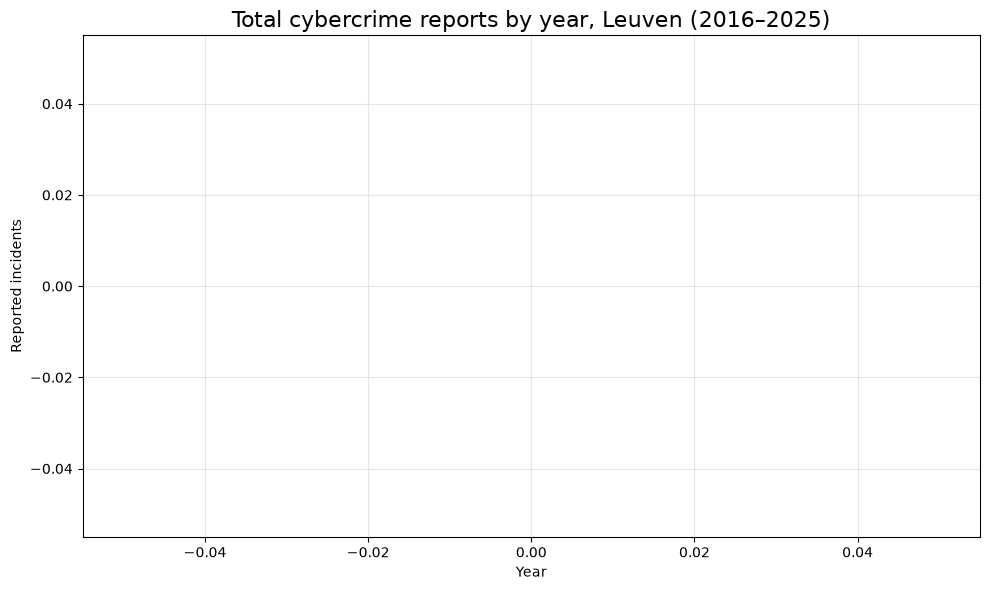

In [34]:
# Plot total cybercrime reports by year
yearly_totals = transposed.groupby('year', as_index=False)['total'].sum()

plt.figure(figsize=(10, 6))
sns.lineplot(data=yearly_totals, x='year', y='total', marker='o')
plt.title('Total cybercrime reports by year, Leuven (2016–2025)', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Reported incidents')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


#### The yearly totals show how reported cybercrime changed in Leuven from 2016 through 2025.

In [35]:
# Group the data by month
transposed.groupby('month', as_index=False)['total'].sum()


,month,total


In [36]:
# Make a list to indext the months 
month_order = ['january', 'february', 'march', 'april', 'may', 'june', 'july',
         'august', 'september', 'october', 'november', 'december']

In [37]:
# Create a dataframe with months in calendar order
total_amount_month = (
    transposed.groupby('month')['total']
    .sum()
    .reindex(month_order)
    .to_frame()
)
total_amount_month


,total
month,
january,NaN
february,NaN
march,NaN
april,NaN
may,NaN
june,NaN
july,NaN
august,NaN
september,NaN


In [38]:
# Plot total cybersecurity incidents by month, stacked by year

stacked_data = (
    transposed
    .pivot_table(
        index='month',
        columns='year',
        values='total',
        aggfunc='sum'
    )
    .reindex(month_order)
)

# Same plasma color scheme as the radial charts
cmap = plt.get_cmap('plasma')
colors = cmap(np.linspace(0.1, 0.9, len(stacked_data.columns)))

ax = stacked_data.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 7),
    color=colors,
    edgecolor='black',
    linewidth=0.5
)

# Add accumulated total above each month
monthly_totals = stacked_data.sum(axis=1)

for i, total in enumerate(monthly_totals):
    ax.text(
        i,
        total + 5,
        f'{int(total)}',
        ha='center',
        va='bottom',
        fontweight='bold',
        fontsize=10
    )

plt.title('Total cybercrime reports by month, Leuven (2016–2025)', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Reported incidents')
plt.xticks(rotation=45)

plt.legend(
    title='Year',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()


NameError: name 'np' is not defined

#### The monthly totals can now be compared with the timing of major technology releases. 
A similar seasonal pattern can suggest an association, but this chart alone does **not** establish causation. 
Other factors such as reporting behavior, holidays, fraud campaigns, and broader growth in cybercrime may also affect the monthly totals.

In [ ]:
# Confirm the year column is an integer
transposed['year'] = transposed['year'].astype(int)
transposed.dtypes


year     int64
month      str
total    int64
dtype: object

In [ ]:
# Create a separate date column instead of converting 'year' itself
transposed['date'] = pd.to_datetime(
    transposed['year'].astype(str) + '-' + transposed['month'],
    format='%Y-%B'
)
transposed.dtypes


year              int64
month               str
total             int64
date     datetime64[us]
dtype: object

In [ ]:
# Number of observations for each month
transposed['month'].value_counts().reindex(month_order)


month
january      10
february     10
march        10
april        10
may          10
june         10
july         10
august       10
september    10
october      10
november     10
december     10
Name: count, dtype: int64

In [ ]:
# Inspect the cleaned dataset
transposed.head()


,year,month,total,date
0,2016,january,33,2016-01-01
1,2016,february,29,2016-02-01
2,2016,march,44,2016-03-01
3,2016,april,40,2016-04-01
4,2016,may,65,2016-05-01


In [ ]:
# The original integer year is preserved; inspect the date and year columns
transposed[['date', 'year', 'month', 'total']].head()


,date,year,month,total
0,2016-01-01,2016,january,33
1,2016-02-01,2016,february,29
2,2016-03-01,2016,march,44
3,2016-04-01,2016,april,40
4,2016-05-01,2016,may,65


In [ ]:
# Check datatypes
transposed.dtypes


year              int64
month               str
total             int64
date     datetime64[us]
dtype: object

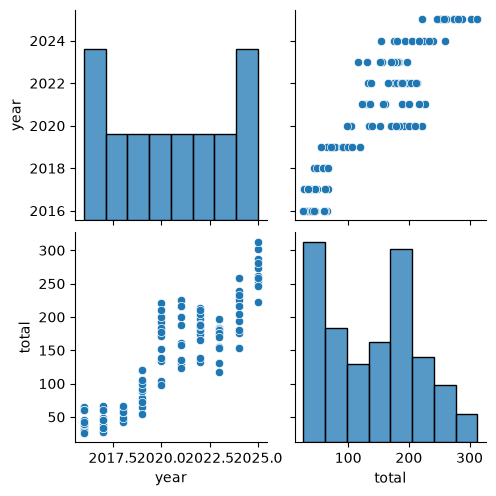

In [ ]:
# Compare numerical variables
sns.pairplot(transposed[['year', 'total']])
plt.show()


In [ ]:
# Create datasets for the earliest and latest years in the file
first_year = int(transposed['year'].min())
last_year = int(transposed['year'].max())

first_year_data = transposed[transposed['year'] == first_year].copy()
last_year_data = transposed[transposed['year'] == last_year].copy()


In [ ]:
first_year_data.head()


,year,month,total,date
0,2016,january,33,2016-01-01
1,2016,february,29,2016-02-01
2,2016,march,44,2016-03-01
3,2016,april,40,2016-04-01
4,2016,may,65,2016-05-01


In [ ]:
last_year_data.head()


,year,month,total,date
108,2025,january,287,2025-01-01
109,2025,february,252,2025-02-01
110,2025,march,273,2025-03-01
111,2025,april,259,2025-04-01
112,2025,may,274,2025-05-01


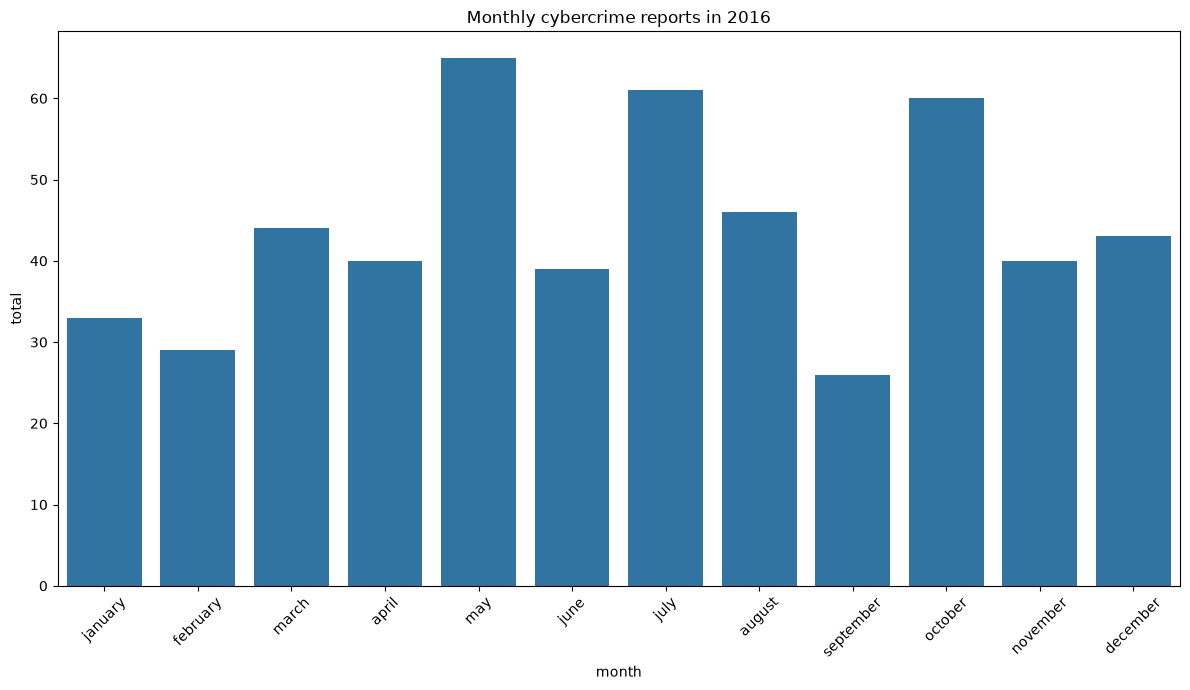

In [ ]:
# Monthly totals for the earliest year
first_year_plot = first_year_data.copy()
first_year_plot['month'] = pd.Categorical(
    first_year_plot['month'], categories=month_order, ordered=True
)
first_year_plot = first_year_plot.sort_values('month')

plt.figure(figsize=(12, 7))
sns.barplot(data=first_year_plot, x='month', y='total')
plt.title(f'Monthly cybercrime reports in {first_year}')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


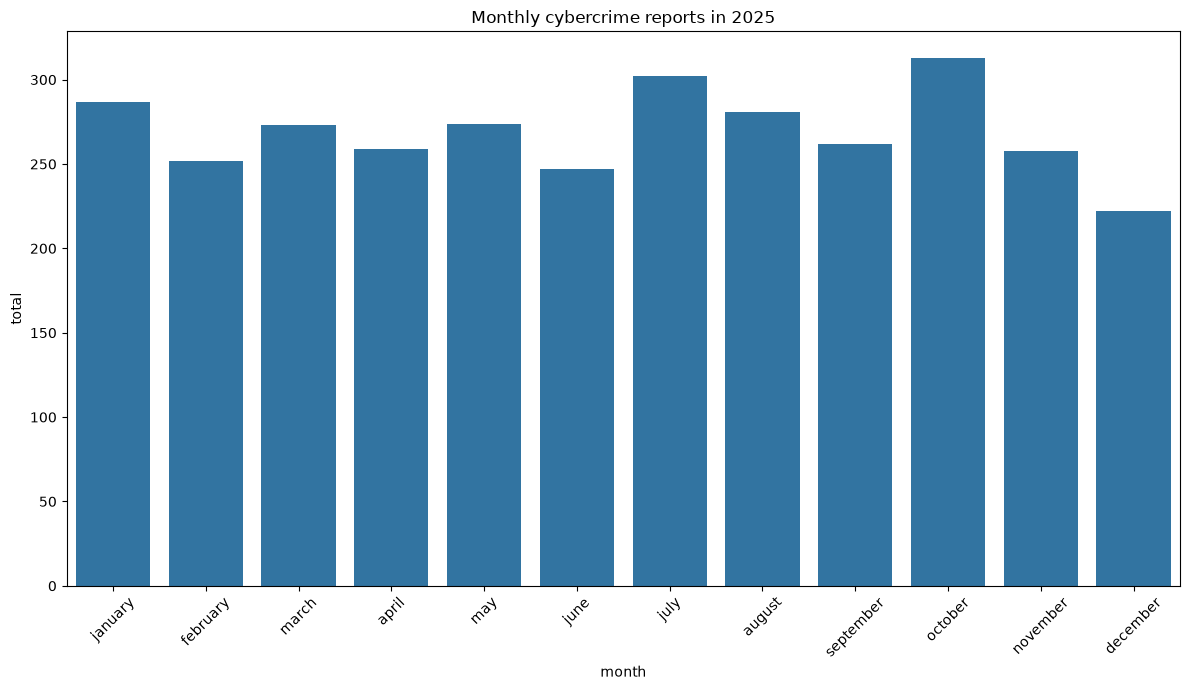

In [ ]:
# Monthly totals for the latest year
last_year_plot = last_year_data.copy()
last_year_plot['month'] = pd.Categorical(
    last_year_plot['month'], categories=month_order, ordered=True
)
last_year_plot = last_year_plot.sort_values('month')

plt.figure(figsize=(12, 7))
sns.barplot(data=last_year_plot, x='month', y='total')
plt.title(f'Monthly cybercrime reports in {last_year}')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Experimenting with data visualization designs.

In [ ]:
# Create a plotting dataframe
df = transposed.copy()

df['year'] = df['year'].astype(int)
df['month'] = df['month'].astype(str)
df['total'] = df['total'].astype(int)

# Date is already available, but recreate it safely if needed
df['date'] = pd.to_datetime(
    df['year'].astype(str) + '-' + df['month'],
    format='%Y-%B'
)

df = df.sort_values('date').reset_index(drop=True)

print(df.dtypes)
df.head()


year              int64
month               str
total             int64
date     datetime64[us]
dtype: object


,year,month,total,date
0,2016,january,33,2016-01-01
1,2016,february,29,2016-02-01
2,2016,march,44,2016-03-01
3,2016,april,40,2016-04-01
4,2016,may,65,2016-05-01


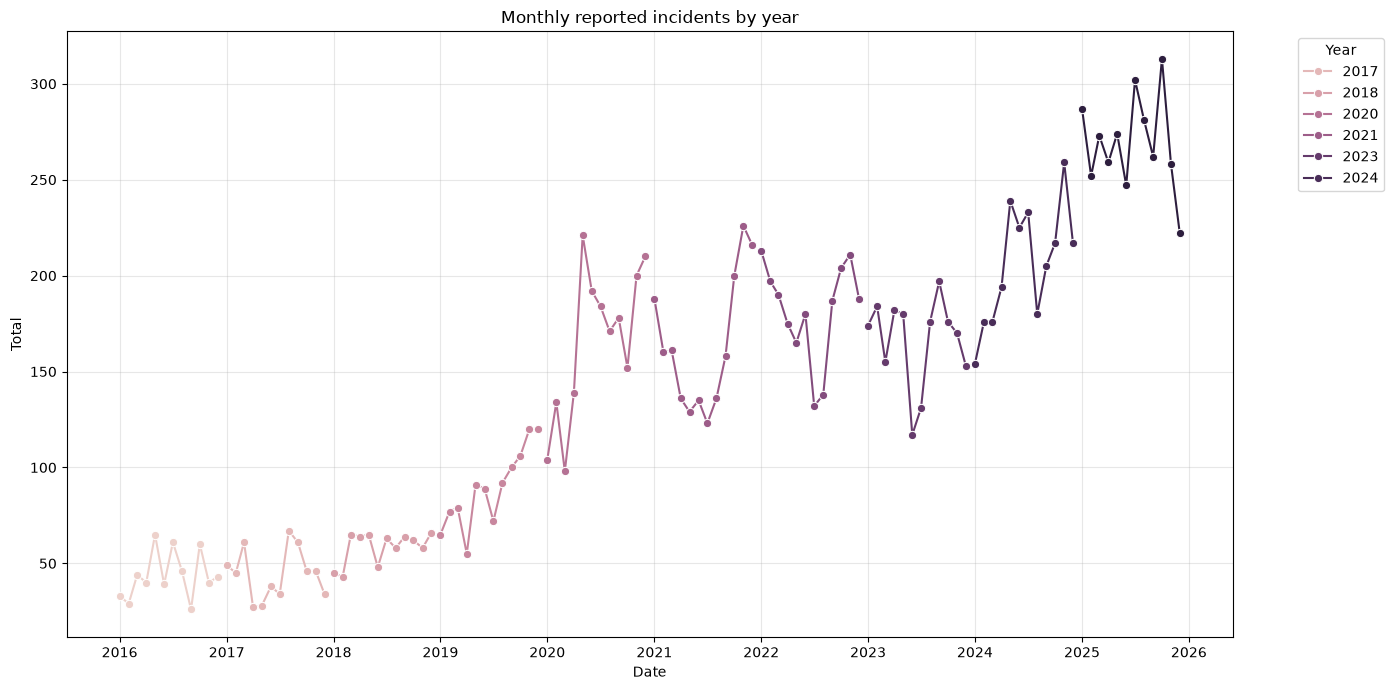

In [ ]:
plt.figure(figsize=(14, 7))
sns.lineplot(data=df, x='date', y='total', hue='year', marker='o')

plt.title('Monthly reported incidents by year')
plt.xlabel('Date')
plt.ylabel('Total')
plt.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


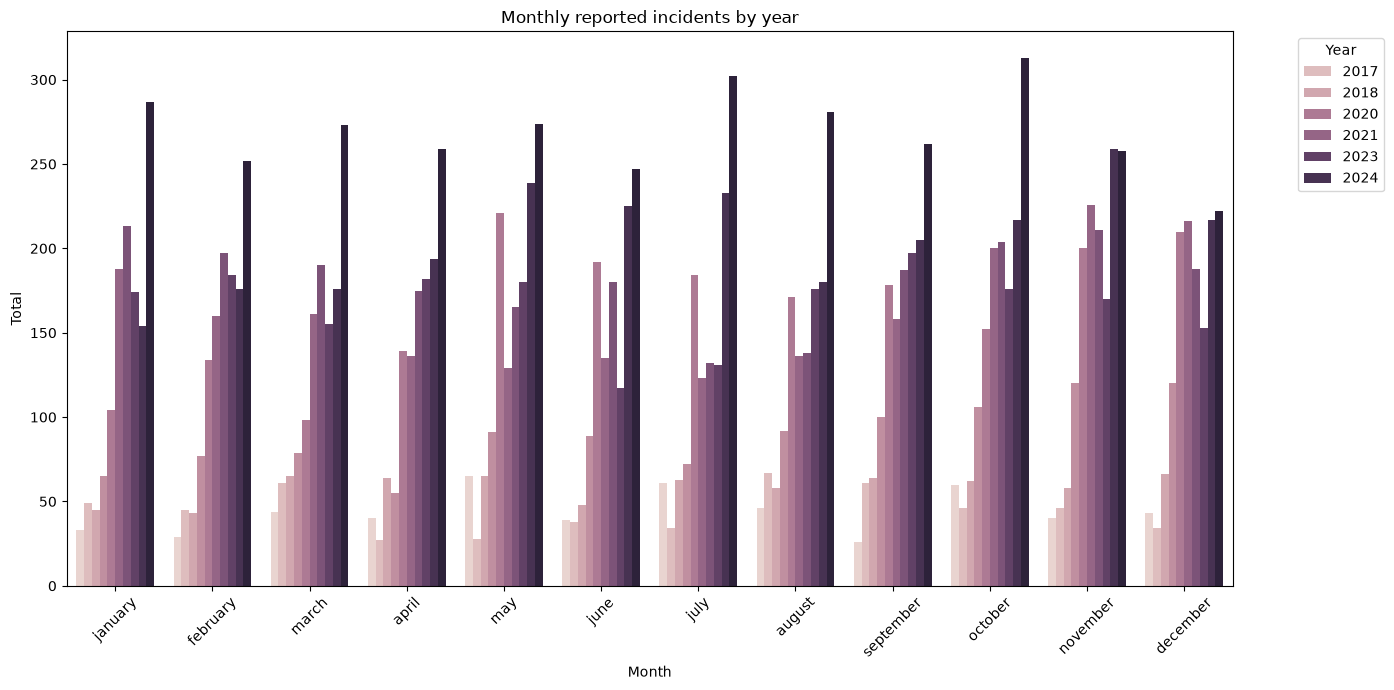

In [ ]:
bar_df = df.copy()
bar_df['month'] = pd.Categorical(bar_df['month'], categories=month_order, ordered=True)

plt.figure(figsize=(14, 7))
sns.barplot(data=bar_df, x='month', y='total', hue='year')

plt.title('Monthly reported incidents by year')
plt.xlabel('Month')
plt.ylabel('Total')
plt.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


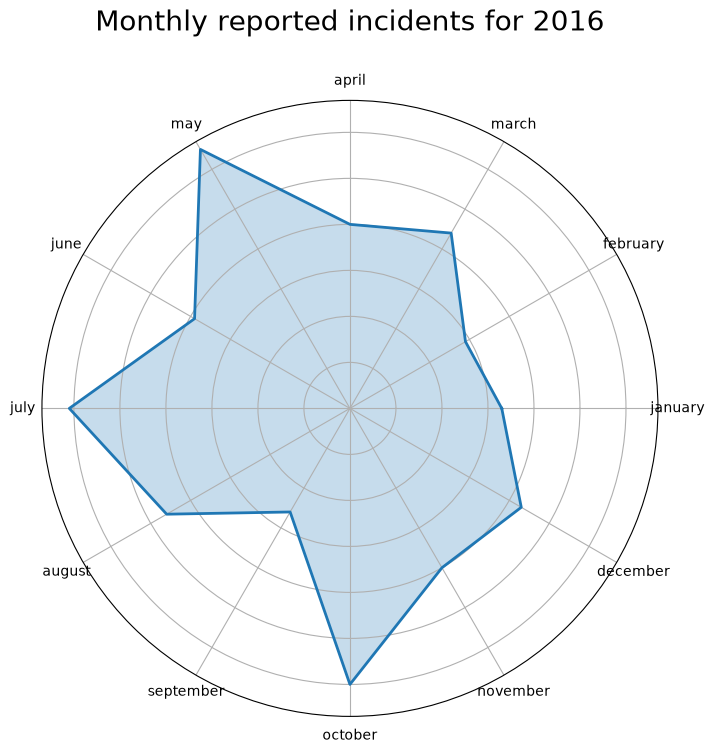

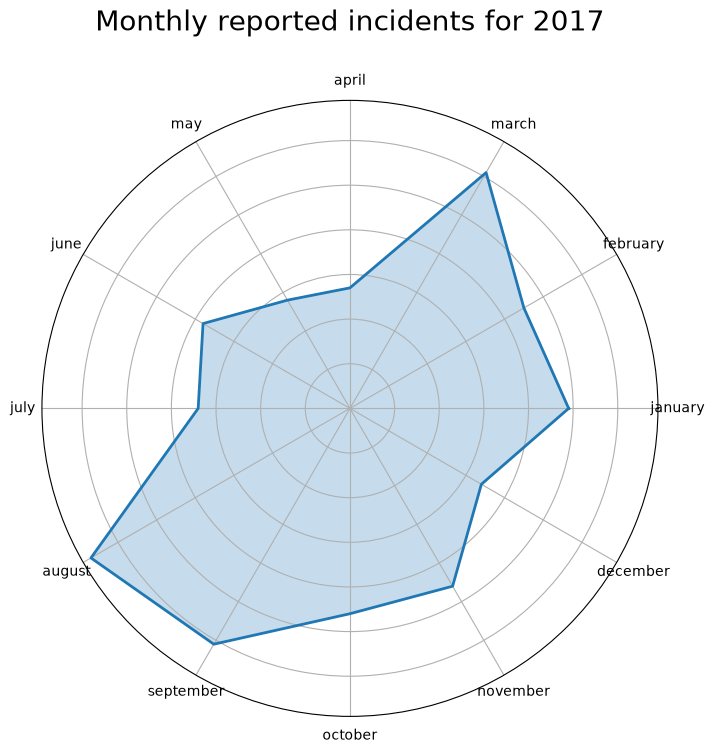

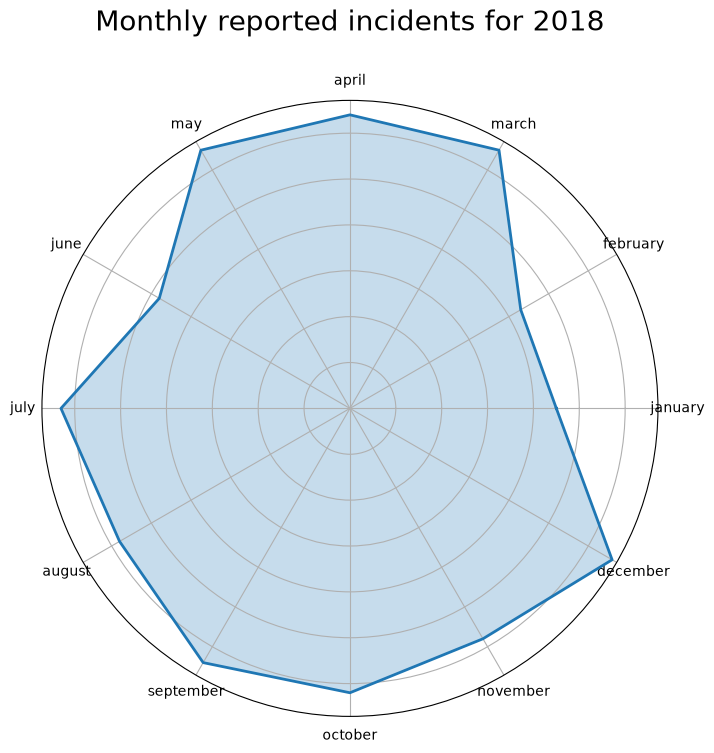

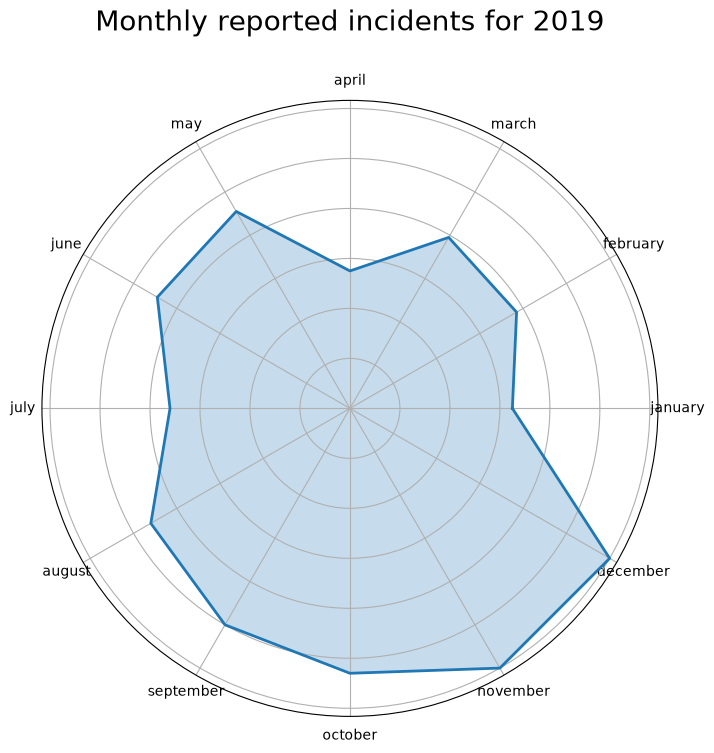

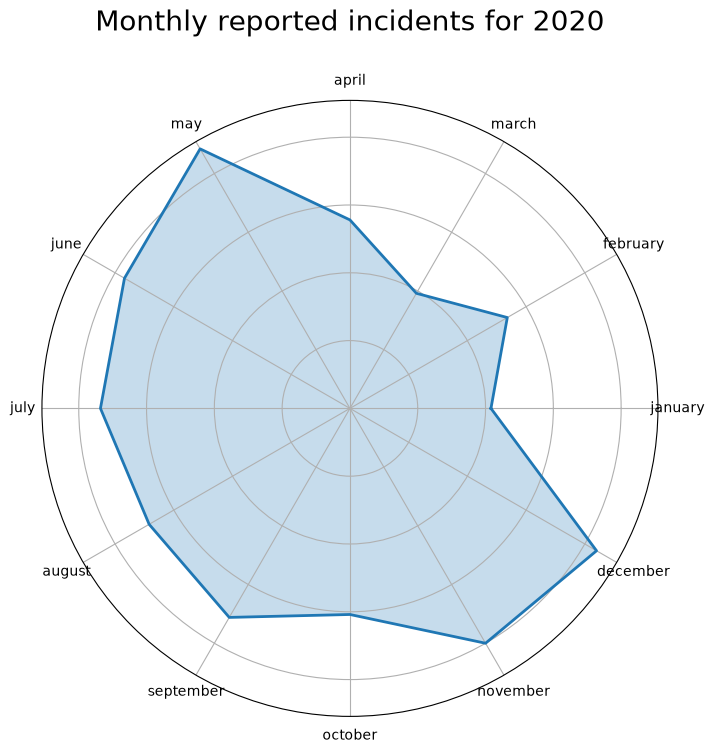

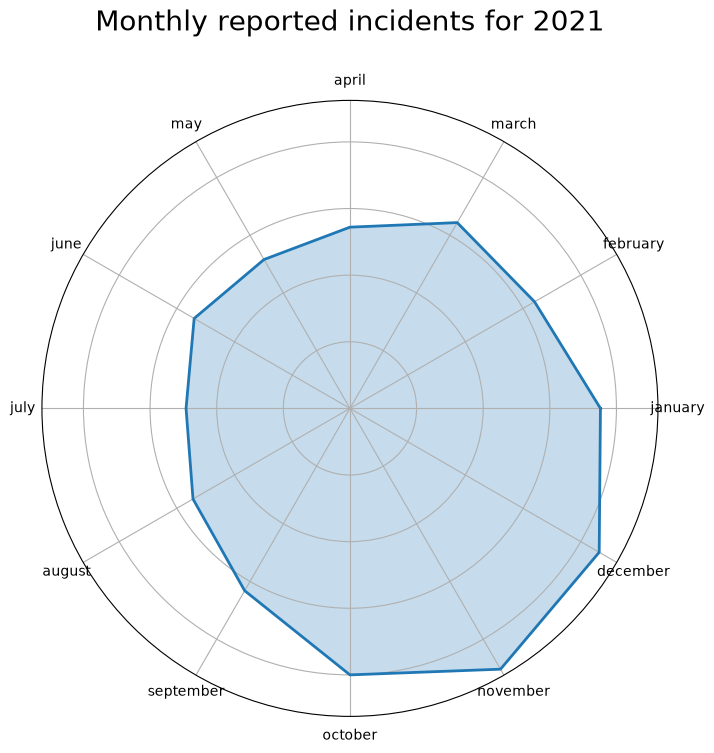

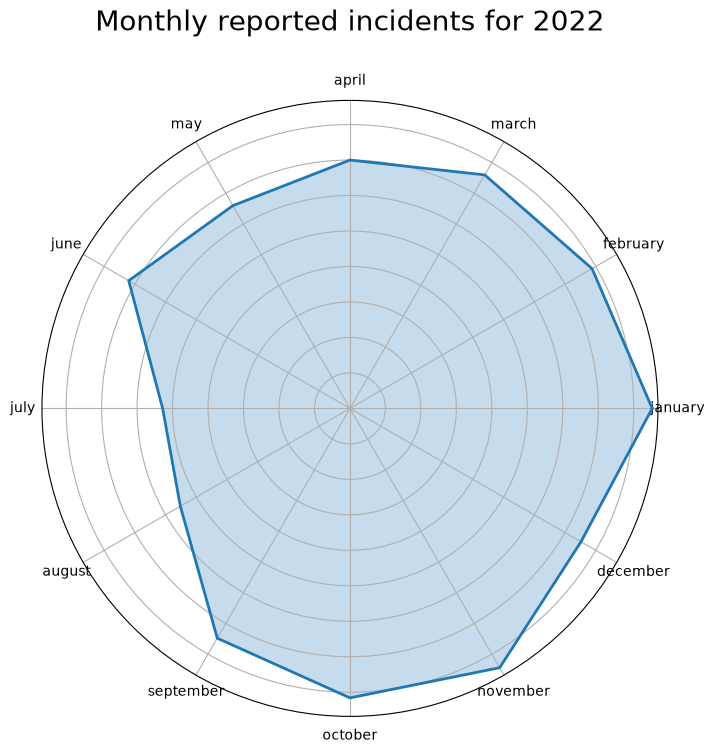

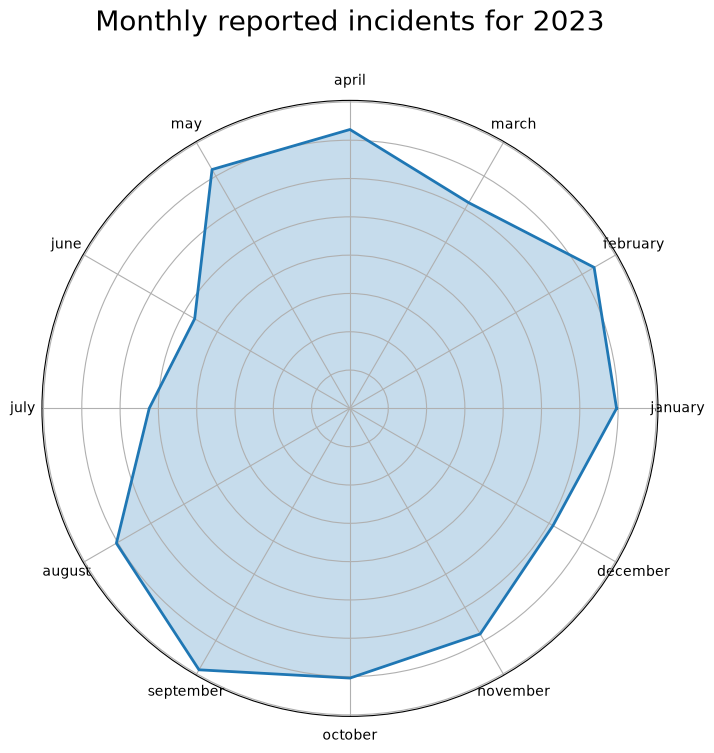

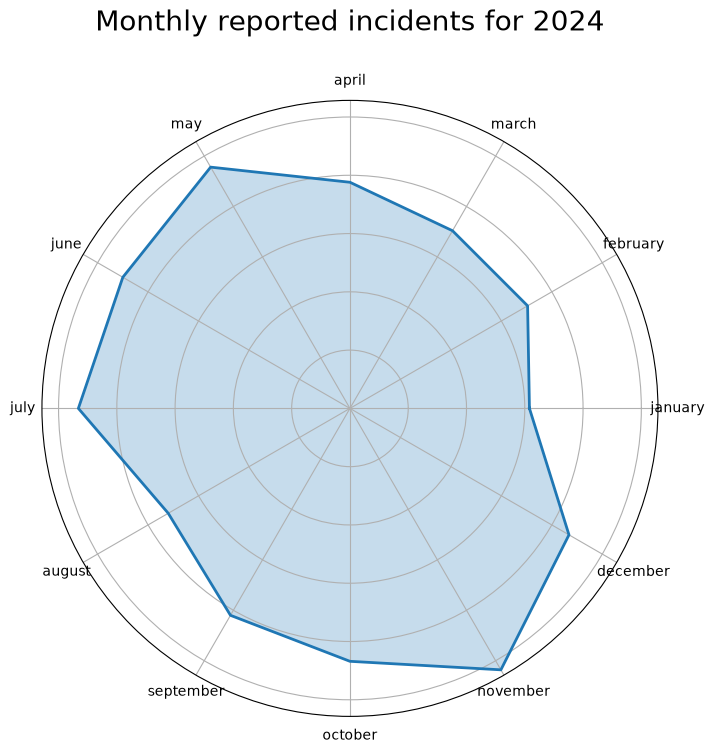

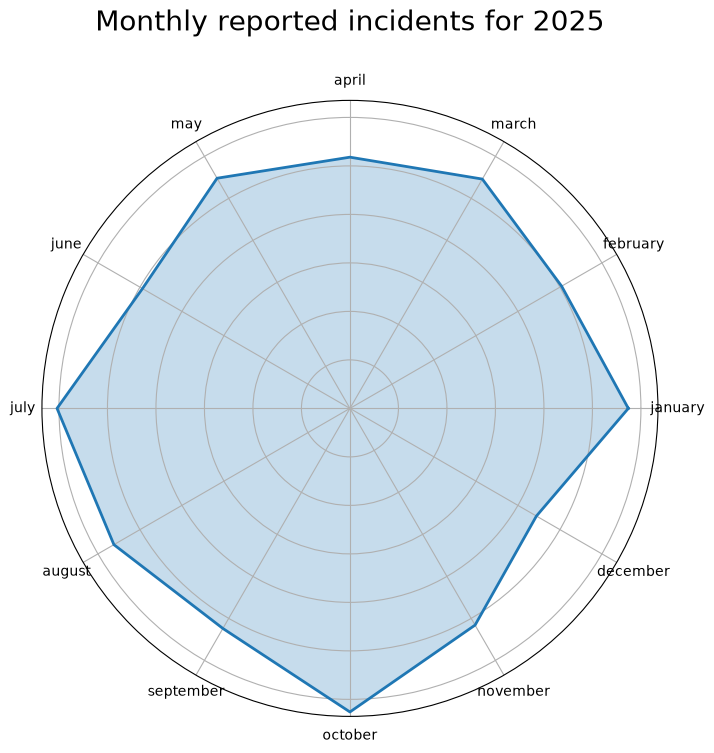

In [ ]:
import numpy as np

# Function to plot a radar chart for one year
def plot_radial_chart(df, year):
    df_year = df[df['year'] == year].copy()
    df_year['month'] = pd.Categorical(df_year['month'], categories=month_order, ordered=True)
    df_year = df_year.sort_values('month')

    labels = df_year['month'].astype(str).tolist()
    values = df_year['total'].to_numpy()
    num_vars = len(labels)

    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    plot_values = np.concatenate([values, [values[0]]])
    plot_angles = angles + angles[:1]

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'polar': True})
    ax.fill(plot_angles, plot_values, alpha=0.25)
    ax.plot(plot_angles, plot_values, linewidth=2)
    ax.set_yticklabels([])
    ax.set_xticks(angles)
    ax.set_xticklabels(labels)
    plt.title(f'Monthly reported incidents for {year}', size=20, y=1.1)
    plt.show()

for year in sorted(df['year'].unique()):
    plot_radial_chart(df, year)


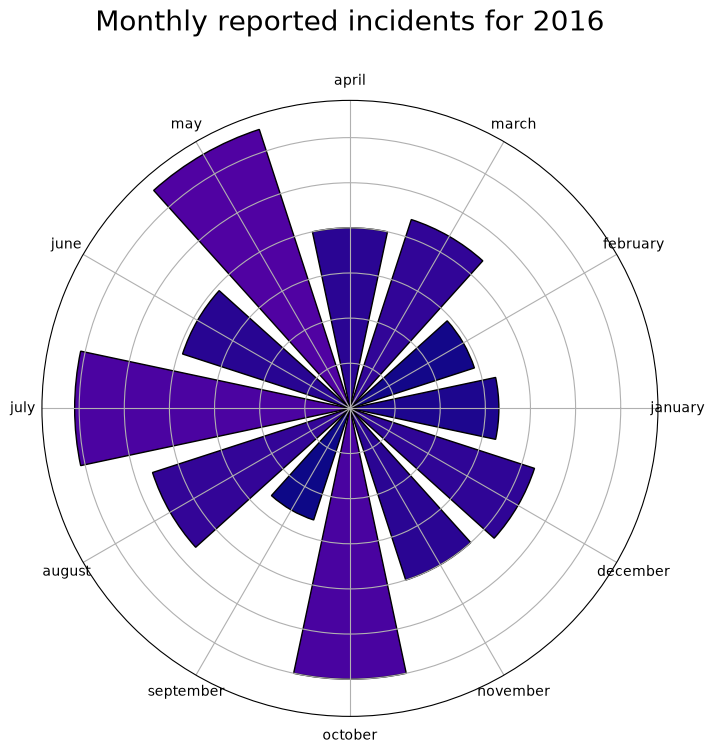

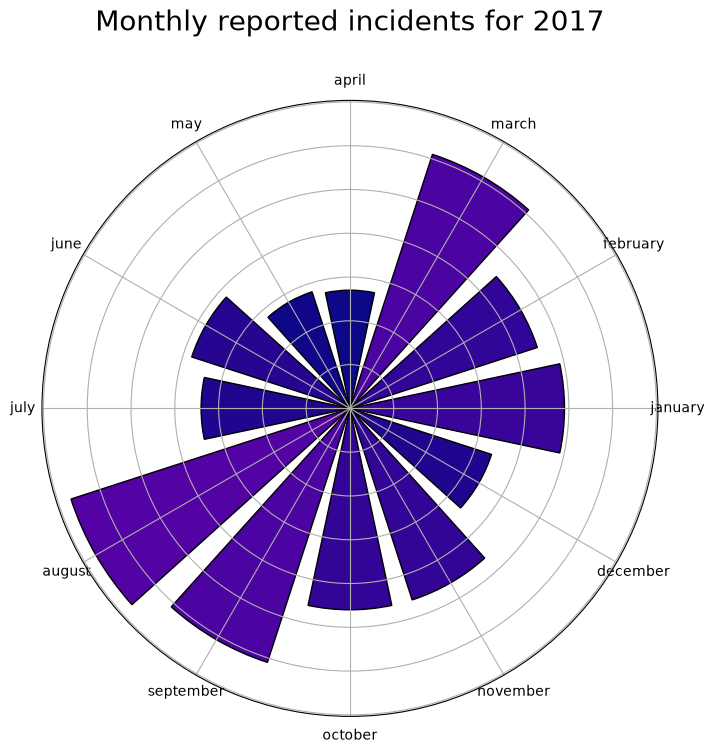

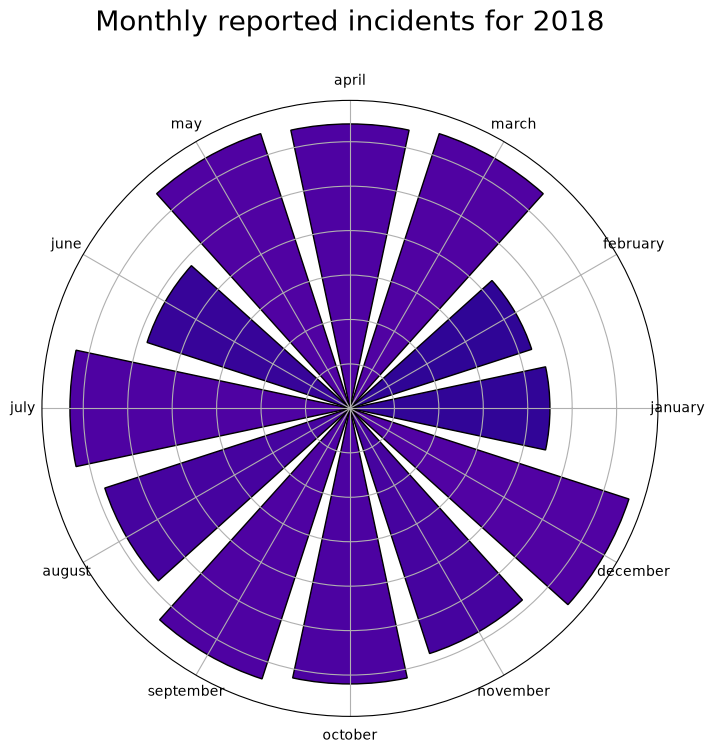

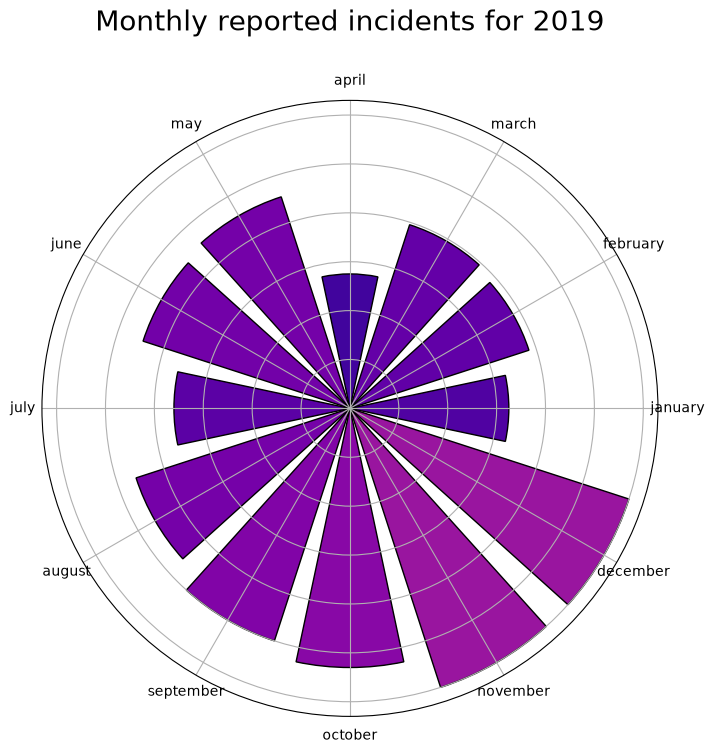

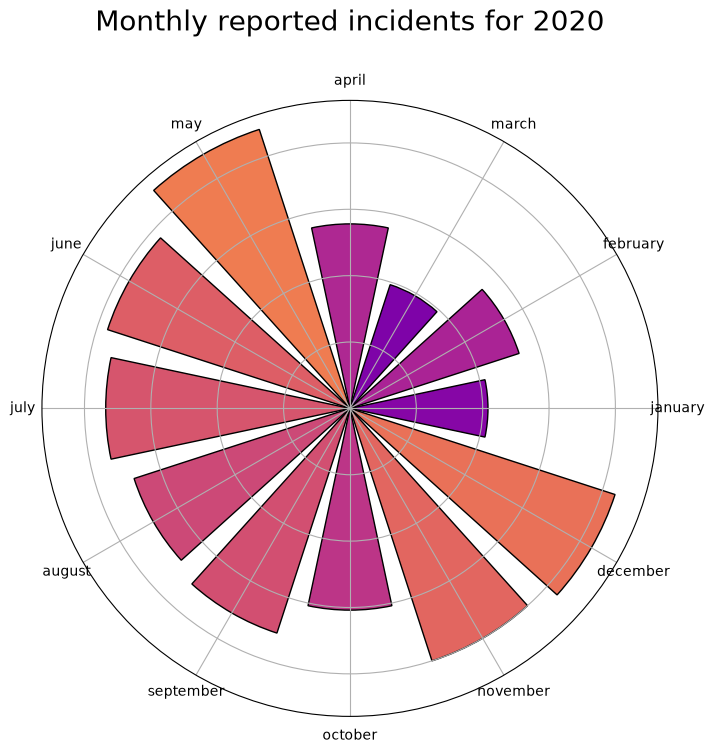

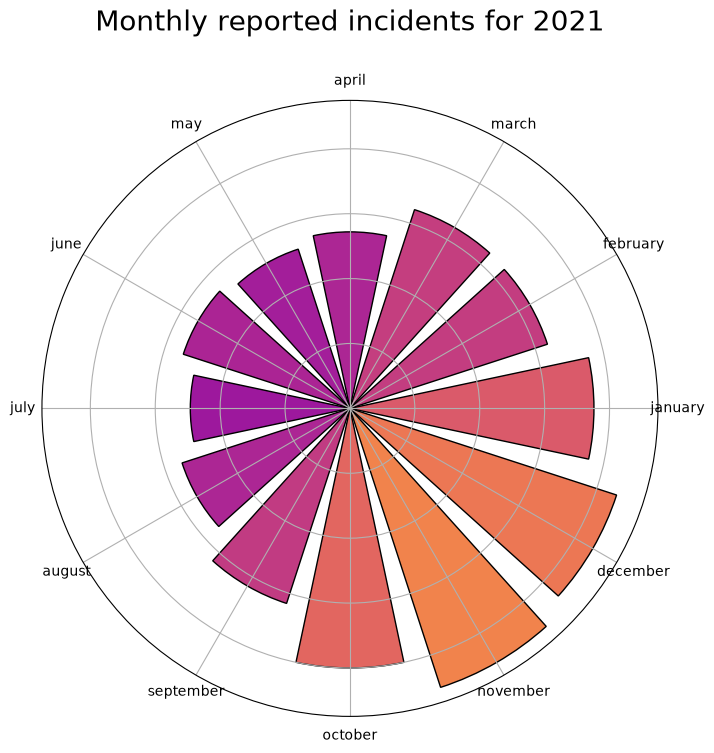

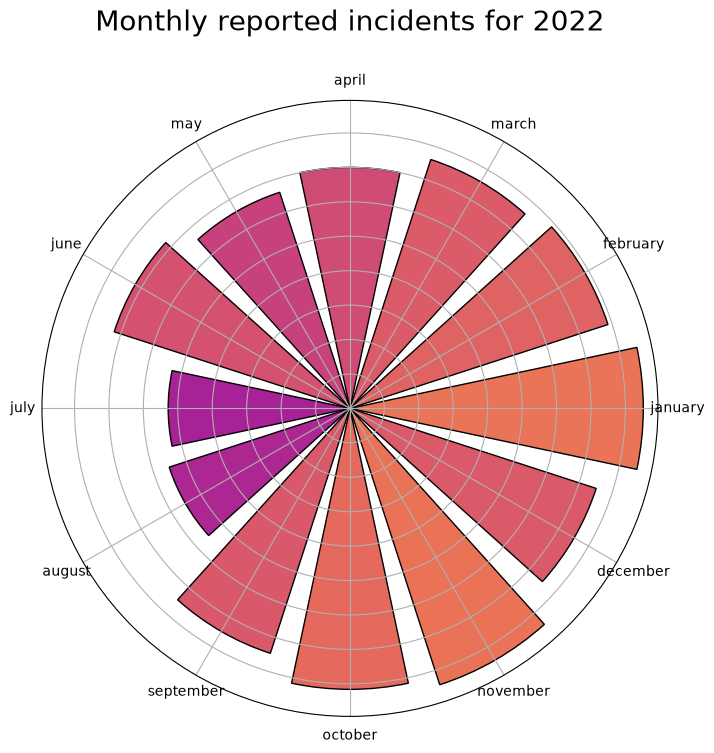

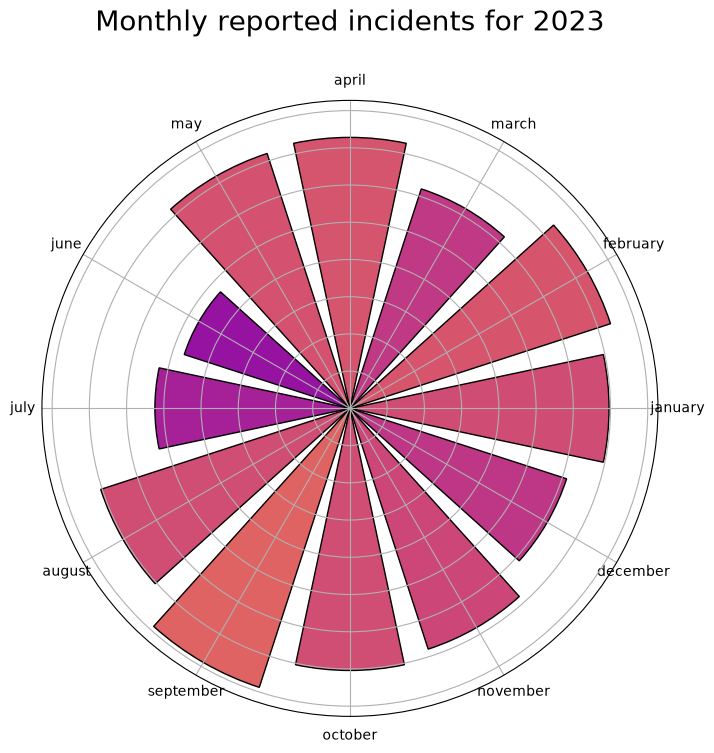

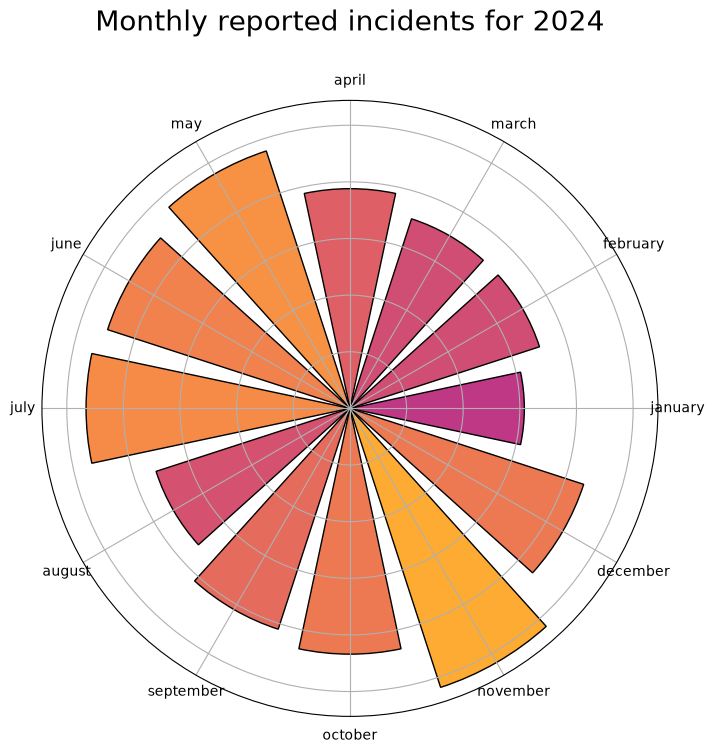

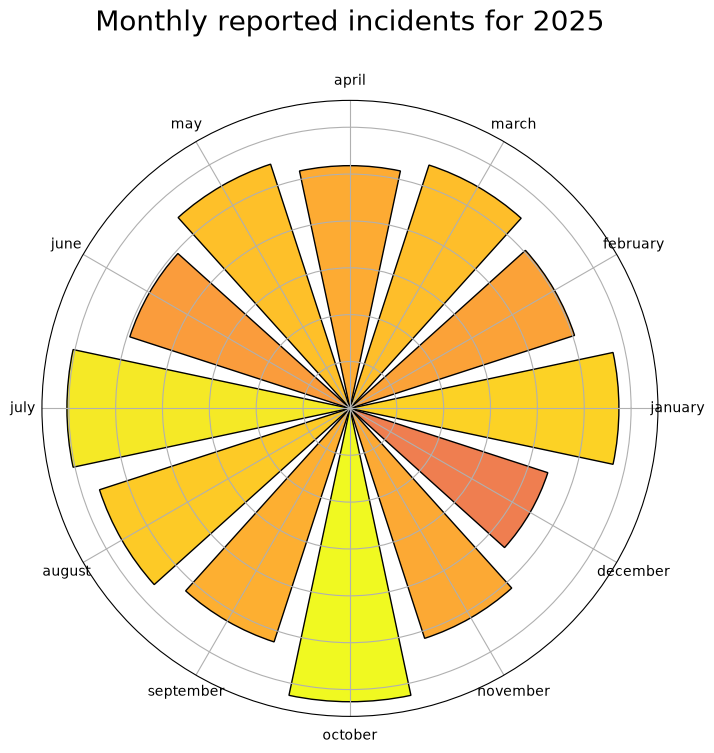

In [ ]:
# Function to plot a radial bar chart with color intensity
def plot_radial_bar_chart(df, year, cmap_name='plasma'):
    df_year = df[df['year'] == year].copy()
    df_year['month'] = pd.Categorical(df_year['month'], categories=month_order, ordered=True)
    df_year = df_year.sort_values('month')

    labels = df_year['month'].astype(str).tolist()
    values = df_year['total'].to_numpy()
    num_vars = len(labels)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False)

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'polar': True})
    norm = plt.Normalize(df['total'].min(), df['total'].max())
    cmap = plt.get_cmap(cmap_name)

    width = (2 * np.pi / num_vars) * 0.8
    for angle, value in zip(angles, values):
        ax.bar(
            angle,
            value,
            color=cmap(norm(value)),
            edgecolor='black',
            linewidth=1,
            width=width
        )

    ax.set_yticklabels([])
    ax.set_xticks(angles)
    ax.set_xticklabels(labels)
    plt.title(f'Monthly reported incidents for {year}', size=20, y=1.1)
    plt.show()

for year in sorted(df['year'].unique()):
    plot_radial_bar_chart(df, year)
